# Glasses Detection Using YOLO12m

## 1. Project Overview

This project presents an end-to-end computer vision pipeline for detecting whether a person is **wearing glasses or not wearing glasses** in an image. The project is implemented as an object detection task using a pretrained **YOLO12m** model from the Ultralytics framework.

Rather than training an object detector from scratch, this project uses **transfer learning**. A YOLO12m model pretrained on a large-scale object detection dataset is used as the starting point and then fine-tuned on a smaller, task-specific glasses detection dataset.

The complete workflow covers the major stages of a computer vision project: dataset preparation, exploratory data analysis (EDA), annotation inspection, data augmentation, model fine-tuning, quantitative evaluation, and qualitative analysis of model predictions.

### Objective

The main objective is to train an object detection model capable of:

- Locating a person's face/glasses region using a bounding box.
- Distinguishing between people who are **wearing glasses** and those who are **not wearing glasses**.
- Generalizing to previously unseen images in a held-out test set.

The two detection classes used throughout the project are:

| Class ID | Class Name | Description |
|---:|---|---|
| `0` | `not_wearing_glasses` | Person/face without glasses |
| `1` | `wearing_glasses` | Person/face wearing glasses |

---

## 2. Why Object Detection?

The task could potentially be approached as an image classification problem if every image contained a single tightly cropped face. However, object detection provides additional spatial information by predicting both:

1. **What is present** — the predicted class.
2. **Where it is located** — the predicted bounding box.

Each annotation therefore follows the YOLO object detection format:

```text
<class_id> <x_center> <y_center> <width> <height>
```

The bounding-box coordinates are normalized relative to the dimensions of the image.

This allows the trained model to simultaneously perform **localization and classification**, making the solution more applicable to images where the subject may appear at different positions or scales.

---

## 3. Dataset

The dataset used in this project is the **Glasses Detection YOLO Format** dataset published on Kaggle:

`https://www.kaggle.com/datasets/mohamedchahed/glasses-detection-yolo-format`

The dataset was downloaded manually as a `.zip` archive and extracted into the project data directory.

The original dataset contains images together with corresponding YOLO `.txt` annotation files. Each image is associated with a label file containing its class and normalized bounding-box coordinates.

### Dataset Preparation

Before training, the downloaded data was processed into a consistent dataset structure suitable for Ultralytics YOLO.

The preparation workflow consisted of the following steps:

1. Download the dataset from Kaggle as a `.zip` archive.
2. Extract the original images and YOLO annotations.
3. Pair every image with its corresponding `.txt` annotation.
4. Restructure the dataset into separate `train`, `val`, and `test` directories.
5. Perform a reproducible stratified split while maintaining a similar distribution of the two classes across the three subsets.
6. Apply data augmentation to the **training set only** to increase its size and introduce additional visual variation.
7. Keep the validation and test images unaugmented so that evaluation is performed using original, unseen samples.

The resulting structure is:

```text
DST_GlassesDet/
│
├── train/
│   ├── images/
│   └── labels/
│
├── val/
│   ├── images/
│   └── labels/
│
├── test/
│   ├── images/
│   └── labels/
│
└── yolo.yaml
```

The preprocessing and augmentation workflow is implemented in:

```text
utils/resplit_and_augment.py
```

### Dataset Split

The original dataset contains **134 images**, distributed between the two classes as follows:

| Class | Original Samples |
|---|---:|
| `not_wearing_glasses` | 59 |
| `wearing_glasses` | 75 |
| **Total** | **134** |

A stratified **80% / 10% / 10%** train-validation-test strategy was applied to preserve approximately the same class distribution across the subsets.

Before augmentation, the resulting split was:

| Split | Not Wearing Glasses | Wearing Glasses | Total |
|---|---:|---:|---:|
| Train | 47 | 60 | 107 |
| Validation | 5 | 7 | 12 |
| Test | 7 | 8 | 15 |
| **Total** | **59** | **75** | **134** |

Because the original dataset is relatively small, additional training examples were generated through data augmentation. The training set was increased from **107 to 321 images**, while the validation and test sets remained unchanged.

It is important to note that augmented images do not represent the same amount of new information as independently collected images. Their purpose is instead to expose the model to controlled variations of the available training data and improve robustness.

---

## 4. Model — YOLO12m

This project uses **YOLO12m** through the Ultralytics framework.

YOLO models are single-stage object detectors designed to perform object localization and classification within a unified neural network. Instead of first generating candidate regions and subsequently classifying them, YOLO predicts detections directly from the input image.

The **medium (`m`)** variant was selected to provide a balance between model capacity and computational requirements.

Rather than initializing the network with random weights, the project starts from:

```python
YOLO("yolo12m.pt")
```

The pretrained model is then fine-tuned for the two glasses-detection classes.

During fine-tuning, the original detection head is adapted from the pretrained model's original classes to:

```text
nc = 2
```

This transfer-learning approach allows previously learned visual features such as edges, shapes, textures, and higher-level object representations to be reused for the new detection task.

---

## 5. Exploratory Data Analysis

Before model training, the notebook performs exploratory data analysis to understand the dataset and identify potential issues that could affect model performance.

The EDA stage examines:

- Number of images and annotations in each split.
- Distribution of the two classes.
- Relative class balance between train, validation, and test.
- Image width and height distributions.
- Image aspect ratios.
- Bounding-box width and height distributions.
- Bounding-box area relative to image size.
- Example images with ground-truth annotations rendered visually.
- Dataset integrity, including missing or malformed image-label pairs.

This stage is particularly important because the dataset is relatively small. Dataset imbalance, incorrect annotations, unusually small bounding boxes, or problematic train/test distributions could substantially influence the final evaluation.

---

## 6. Training Strategy

The pretrained YOLO12m model is fine-tuned using the prepared training set.

The experiment uses:

- **Input resolution:** `640 × 640`
- **Batch size:** `8`
- **Maximum epochs:** `100`
- **Optimizer:** AdamW
- **Initial learning rate:** `0.001`
- **Early stopping patience:** `20`
- **Random seed:** `42`
- **Pretrained weights:** `yolo12m.pt`
- **GPU acceleration:** CUDA when available

Early stopping is used because the dataset is small and prolonged training could lead to overfitting. The checkpoint with the strongest validation performance is retained as `best.pt` and used for final evaluation.

Because offline augmentation has already been applied during dataset preparation, additional online augmentation during training is intentionally kept relatively conservative.

---

# 7. Evaluation Strategy

Model performance is evaluated using the validation set during development and the held-out **test set** for final evaluation.

The validation set is used to monitor the model during training and determine the best-performing checkpoint. The final `best.pt` checkpoint is then evaluated on the test set, which contains images that were not used for training or data augmentation.

Several complementary metrics are used because no single metric completely describes the performance of an object detection model.

### Precision

Precision measures how many detections produced by the model are correct.

\[
Precision = \frac{TP}{TP + FP}
\]

where:

- **TP (True Positive):** a correct detection.
- **FP (False Positive):** an incorrect detection.

High precision indicates that when the model predicts an object, that prediction is likely to be correct. In this project, low precision could indicate that the model is incorrectly detecting or classifying glasses-related objects.

### Recall

Recall measures how many of the actual ground-truth objects were successfully detected by the model.

\[
Recall = \frac{TP}{TP + FN}
\]

where:

- **FN (False Negative):** a ground-truth object that the model failed to detect.

High recall indicates that the model successfully finds most of the objects that are actually present. Low recall would indicate that the detector is frequently missing people belonging to one of the two glasses classes.

### F1 Score

The F1 score is the harmonic mean of precision and recall:

\[
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
\]

The F1 score provides a single measurement representing the balance between precision and recall. A high F1 score therefore requires the model to maintain both relatively few false positives and relatively few false negatives.

### Mean Average Precision (mAP)

Mean Average Precision is one of the primary metrics used to evaluate object detection models because it considers both classification and bounding-box localization performance.

Two mAP measurements are reported in this project:

- **mAP@0.50:** A prediction is considered a valid match when its bounding box reaches an Intersection over Union (IoU) threshold of at least `0.50` with the corresponding ground-truth box.
- **mAP@0.50:0.95:** Average Precision is calculated across multiple IoU thresholds ranging from `0.50` to `0.95`. This is a stricter metric because the predicted bounding boxes must increasingly align with the ground-truth boxes as the IoU threshold increases.

### Per-Class Evaluation

In addition to overall model performance, the evaluation examines the two classes independently:

- `not_wearing_glasses`
- `wearing_glasses`

Per-class precision, recall, and mAP help determine whether the model performs similarly on both classes or whether one class is more difficult to detect correctly.

### Evaluation Visualizations

Numerical metrics are complemented by several visual evaluation tools generated during the experiment:

- **Confusion Matrix** — shows how predictions are distributed between the two classes and background errors.
- **Precision-Recall Curve** — visualizes the trade-off between precision and recall.
- **F1-Confidence Curve** — shows how the F1 score changes as the detection confidence threshold changes.
- **Precision-Confidence Curve** — shows how precision changes with confidence threshold.
- **Recall-Confidence Curve** — shows how recall changes with confidence threshold.
- **Qualitative Predictions** — displays predicted bounding boxes, classes, and confidence scores on held-out test images.

Together, these measurements provide a more complete assessment of the detector than relying on a single performance metric.

### Test-Set Considerations

The final test set contains **15 original images** and is intentionally kept separate from both training and augmentation.

Because this is a relatively small test set, the final metrics can be sensitive to individual predictions. A small number of correct or incorrect detections may noticeably change precision, recall, or mAP.

For this reason, the quantitative results are interpreted together with the confusion matrix, evaluation curves, and visual inspection of predictions on unseen images.

### Real-Time Demonstration

After the quantitative evaluation, the best trained YOLO12m checkpoint is also tested using a **live webcam stream**.

Each webcam frame is passed through the trained detector, and the predicted bounding boxes, class labels, and confidence scores are displayed in real time.

This demonstration provides a practical qualitative example of the model operating on previously unseen real-world input. It is **not part of the quantitative test-set evaluation**, and the held-out test set remains the primary source of reported model performance.

### Mean Average Precision

Two standard object detection measurements are reported:

- **mAP@0.50** — Average Precision using an Intersection over Union (IoU) threshold of 0.50.
- **mAP@0.50:0.95** — Average Precision calculated across IoU thresholds from 0.50 to 0.95, providing a stricter assessment of both detection and localization quality.

Performance is analyzed both globally and separately for the two classes.

The notebook additionally examines:

- Confusion matrix.
- Precision-recall curve.
- F1-confidence curve.
- Precision-confidence curve.
- Recall-confidence curve.
- Training and validation losses.
- Qualitative predictions on held-out test images.

---

## 8. Notebook Workflow

The notebook follows the complete experimental pipeline in sequence:

1. **Environment Setup**
   - Import dependencies.
   - Configure paths.
   - Verify CUDA/GPU availability.

2. **Dataset Integrity Analysis**
   - Discover images and labels.
   - Validate YOLO annotations.
   - Detect missing or malformed files.

3. **Exploratory Data Analysis**
   - Analyze split sizes.
   - Analyze class distributions.
   - Inspect image dimensions and bounding-box statistics.

4. **Ground-Truth Visualization**
   - Render YOLO annotations on representative images.
   - Visually inspect annotation quality.

5. **Model Initialization**
   - Load pretrained YOLO12m weights.
   - Configure the model for two-class detection.

6. **Fine-Tuning**
   - Train on the prepared training dataset.
   - Monitor validation performance.
   - Save the best-performing checkpoint.

7. **Model Evaluation**
   - Evaluate `best.pt` against validation and held-out test data.
   - Calculate precision, recall, F1, mAP@0.50, and mAP@0.50:0.95.

8. **Per-Class Analysis**
   - Compare performance between `not_wearing_glasses` and `wearing_glasses`.

9. **Qualitative Evaluation**
   - Run inference on unseen test images.
   - Visualize predicted classes, bounding boxes, and confidence scores.

10. **Final Analysis**
    - Summarize model performance.
    - Examine limitations and potential improvements.

---

## 9. Experimental Considerations

The relatively small size of the original dataset is an important limitation of this experiment. Although augmentation increases the number of training samples, augmented samples remain transformations of the original images rather than independently collected observations.

The validation set contains **12 original images**, while the final test set contains **15 original images**. Consequently, a small number of incorrect predictions can noticeably affect the reported metrics.

For this reason, the project evaluates the model using several complementary measurements rather than relying on a single score. Quantitative metrics are also considered alongside qualitative inspection of predictions on unseen test images.

The experiment should therefore be interpreted as a demonstration of a complete **transfer-learning-based object detection workflow** rather than as evidence of production-level glasses detection performance.

## 10. Real-Time Webcam Detection

As a final practical demonstration, the trained YOLO12m model is applied to a live webcam stream.

Frames are captured from the webcam using OpenCV and passed directly to the fine-tuned `best.pt` checkpoint. For every frame, the model predicts bounding boxes, class labels, and confidence scores for the two target classes:

- `not_wearing_glasses`
- `wearing_glasses`

The resulting detections are rendered on the captured frame and displayed directly inside the Jupyter Notebook.

A confidence threshold of **0.30** is used for the real-time demonstration. Predictions below this threshold are excluded from the displayed results.

This demonstration serves as a **qualitative real-world test** of the trained detector and is separate from the quantitative evaluation performed on the held-out test set. The test-set metrics remain the primary measurements used to assess model performance.

## 1. Setup


In [1]:
# Run once if the environment does not already contain the dependencies.
# %pip install -U ultralytics pandas matplotlib pillow pyyaml

In [2]:
from pathlib import Path
from collections import Counter
import random
import math
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import yaml
import torch

from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATASET_DIR = Path(r".\data\DST_GlassesDet")
DATASET_YAML = DATASET_DIR / "yolo.yaml"
PROJECT_DIR = Path(r".\runs")
RUN_NAME = "yolo12m_glassesdet_notebook"
MODEL_WEIGHTS = "yolo12m.pt"

CLASS_NAMES = {0: "not_wearing_glasses", 1: "wearing_glasses"}
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

assert DATASET_DIR.exists(), f"Dataset directory not found: {DATASET_DIR}"
assert DATASET_YAML.exists(), f"Dataset YAML not found: {DATASET_YAML}"

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"Dataset: {DATASET_DIR}")


PyTorch: 2.14.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 4090 Laptop GPU
VRAM: 16.0 GB
Dataset: data\DST_GlassesDet


## 2. Dataset configuration


In [3]:
with DATASET_YAML.open("r", encoding="utf-8") as f:
    dataset_config = yaml.safe_load(f)

dataset_config


{'path': 'C:/Users/oalyami/CAV-DDE/Repos/External/GlassesDet/data/DST_GlassesDet/',
 'train': 'train/images',
 'val': 'val/images',
 'test': 'test/images',
 'names': {0: 'not_wearing_glasses', 1: 'wearing_glasses'}}

## 3. Build an annotation index

Each YOLO label row is interpreted as `class_id x_center y_center width height`, with coordinates normalized to image dimensions.


In [4]:
def image_files(directory: Path):
    if not directory.exists():
        return []
    return sorted([p for p in directory.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS])

def read_yolo_labels(label_path: Path):
    rows = []
    if not label_path.exists():
        return rows
    text = label_path.read_text(encoding="utf-8").strip()
    if not text:
        return rows
    for line in text.splitlines():
        parts = line.split()
        if len(parts) != 5:
            raise ValueError(f"Unexpected YOLO row in {label_path}: {line}")
        cls, xc, yc, w, h = parts
        rows.append((int(float(cls)), float(xc), float(yc), float(w), float(h)))
    return rows

image_records = []
annotation_records = []

for split in ["train", "val", "test"]:
    img_dir = DATASET_DIR / split / "images"
    lbl_dir = DATASET_DIR / split / "labels"
    for img_path in image_files(img_dir):
        label_path = lbl_dir / f"{img_path.stem}.txt"
        with Image.open(img_path) as im:
            width, height = im.size
        labels = read_yolo_labels(label_path)
        image_records.append({
            "split": split, "image": img_path.name, "image_path": str(img_path),
            "label_path": str(label_path), "width": width, "height": height,
            "objects": len(labels), "has_label_file": label_path.exists(),
        })
        for cls, xc, yc, w, h in labels:
            annotation_records.append({
                "split": split, "image": img_path.name, "class_id": cls,
                "class_name": CLASS_NAMES.get(cls, f"class_{cls}"),
                "x_center": xc, "y_center": yc, "bbox_width": w, "bbox_height": h,
                "bbox_area": w * h, "aspect_ratio": w / h if h else np.nan,
                "image_width": width, "image_height": height,
            })

images_df = pd.DataFrame(image_records)
annotations_df = pd.DataFrame(annotation_records)
print(f"Images: {len(images_df):,}")
print(f"Annotations: {len(annotations_df):,}")
images_df.head()


Images: 348
Annotations: 367


,split,image,image_path,label_path,width,height,objects,has_label_file
0,train,child-children-girl-happy.jpg,data\DST_GlassesDet\train\images\child-childre...,data\DST_GlassesDet\train\labels\child-childre...,4713,3168,1,True
1,train,child-children-girl-happy_aug_0011.jpg,data\DST_GlassesDet\train\images\child-childre...,data\DST_GlassesDet\train\labels\child-childre...,4713,3168,1,True
2,train,child-children-girl-happy_aug_0118.jpg,data\DST_GlassesDet\train\images\child-childre...,data\DST_GlassesDet\train\labels\child-childre...,4713,3168,1,True
3,train,pexels-photo-10131170.jpeg,data\DST_GlassesDet\train\images\pexels-photo-...,data\DST_GlassesDet\train\labels\pexels-photo-...,6000,4000,1,True
4,train,pexels-photo-10131170_aug_0014.jpg,data\DST_GlassesDet\train\images\pexels-photo-...,data\DST_GlassesDet\train\labels\pexels-photo-...,6000,4000,1,True


## 4. Integrity audit


In [5]:
expected_splits = {"train", "val", "test"}
unknown_classes = sorted(set(annotations_df["class_id"]) - set(CLASS_NAMES)) if len(annotations_df) else []
missing_labels = images_df.loc[~images_df["has_label_file"], ["split", "image"]]
empty_images = images_df.loc[images_df["objects"] == 0, ["split", "image"]]
invalid_boxes = annotations_df[(annotations_df[["x_center", "y_center", "bbox_width", "bbox_height"]] < 0).any(axis=1) |
                               (annotations_df[["x_center", "y_center", "bbox_width", "bbox_height"]] > 1).any(axis=1)] if len(annotations_df) else pd.DataFrame()

print(f"Missing label files : {len(missing_labels)}")
print(f"Images with 0 boxes : {len(empty_images)}")
print(f"Unknown class IDs   : {unknown_classes}")
print(f"Invalid normalized boxes: {len(invalid_boxes)}")

assert not unknown_classes, f"Unexpected classes: {unknown_classes}"
assert len(missing_labels) == 0, "Some images do not have matching label files."
assert len(invalid_boxes) == 0, "Some YOLO boxes contain coordinates outside [0, 1]."


Missing label files : 0
Images with 0 boxes : 0
Unknown class IDs   : []
Invalid normalized boxes: 0


## 5. EDA — split sizes and class distribution


In [6]:
split_summary = images_df.groupby("split").size().reindex(["train", "val", "test"], fill_value=0).rename("images").to_frame()
split_summary["percent"] = split_summary["images"] / split_summary["images"].sum() * 100
split_summary


,images,percent
split,,
train,321,92.241379
val,12,3.448276
test,15,4.310345


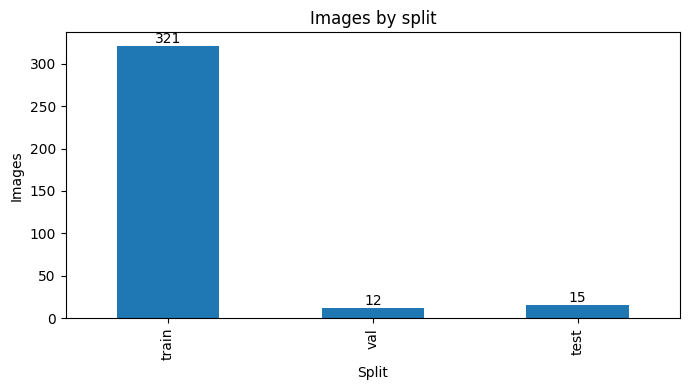

In [7]:
ax = split_summary["images"].plot(kind="bar", figsize=(7, 4), title="Images by split")
ax.set_xlabel("Split")
ax.set_ylabel("Images")
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()


In [8]:
class_split = (annotations_df.groupby(["split", "class_name"]).size().unstack(fill_value=0)
               .reindex(["train", "val", "test"], fill_value=0))
class_split


class_name,not_wearing_glasses,wearing_glasses
split,,
train,144,195
val,5,8
test,7,8


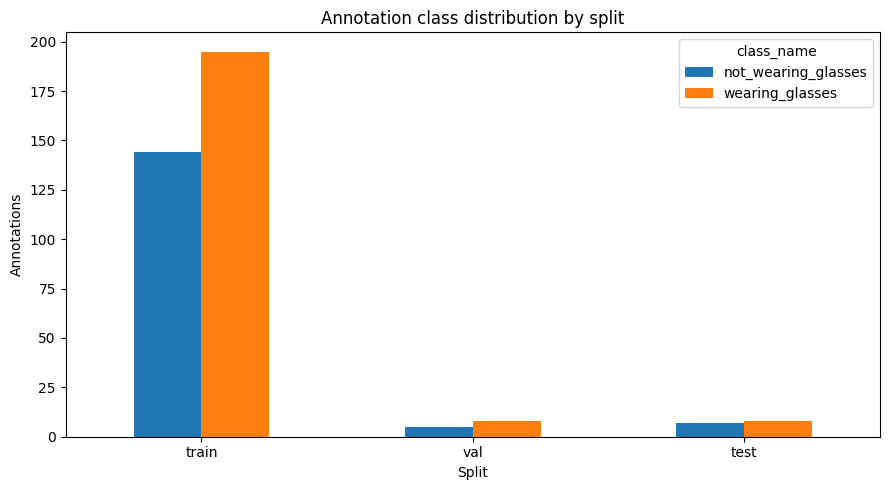

In [9]:
ax = class_split.plot(kind="bar", figsize=(9, 5), title="Annotation class distribution by split")
ax.set_xlabel("Split")
ax.set_ylabel("Annotations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


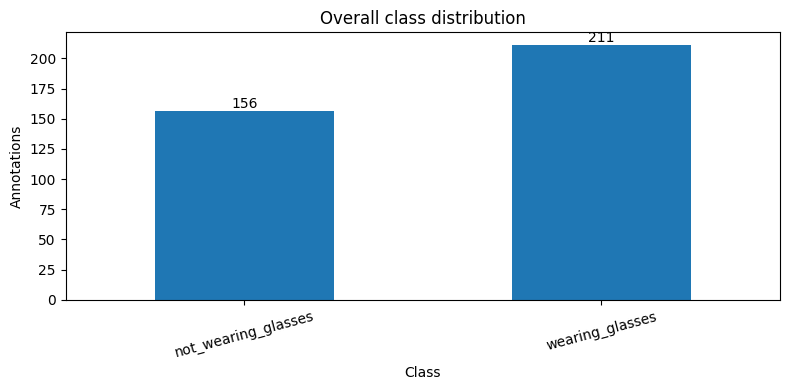

In [10]:
class_totals = annotations_df["class_name"].value_counts().reindex(CLASS_NAMES.values(), fill_value=0)
ax = class_totals.plot(kind="bar", figsize=(8, 4), title="Overall class distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Annotations")
ax.bar_label(ax.containers[0])
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 6. EDA — image and bounding-box characteristics


In [11]:
resolution_summary = images_df[["width", "height", "objects"]].describe().round(2)
resolution_summary


,width,height,objects
count,348.00,348.00,348.00
mean,4156.19,4245.87,1.05
std,1378.35,1304.93,0.29
min,1667.00,1424.00,1.00
25%,3208.00,3431.25,1.00
50%,4000.00,4000.00,1.00
75%,5184.00,5472.00,1.00
max,7952.00,7360.00,3.00


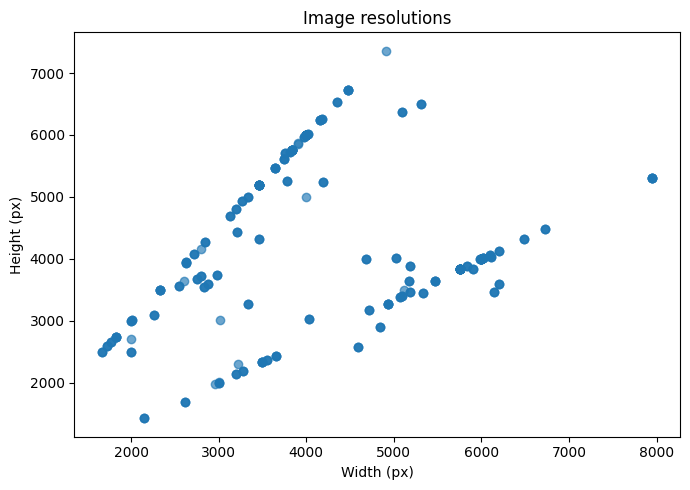

In [12]:
plt.figure(figsize=(7, 5))
plt.scatter(images_df["width"], images_df["height"], alpha=0.65)
plt.title("Image resolutions")
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.tight_layout()
plt.show()


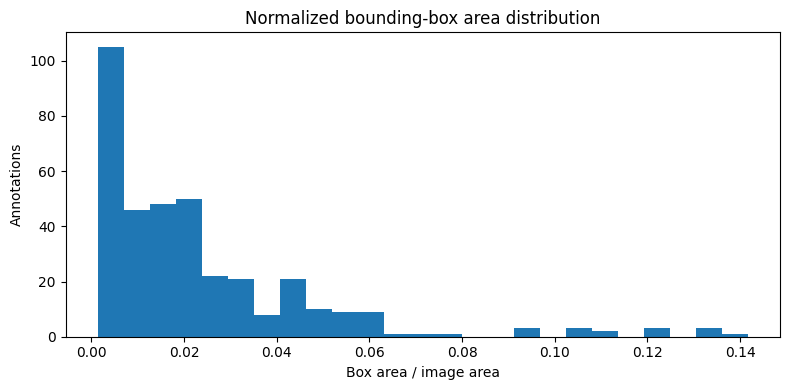

In [13]:
fig = plt.figure(figsize=(8, 4))
plt.hist(annotations_df["bbox_area"], bins=25)
plt.title("Normalized bounding-box area distribution")
plt.xlabel("Box area / image area")
plt.ylabel("Annotations")
plt.tight_layout()
plt.show()


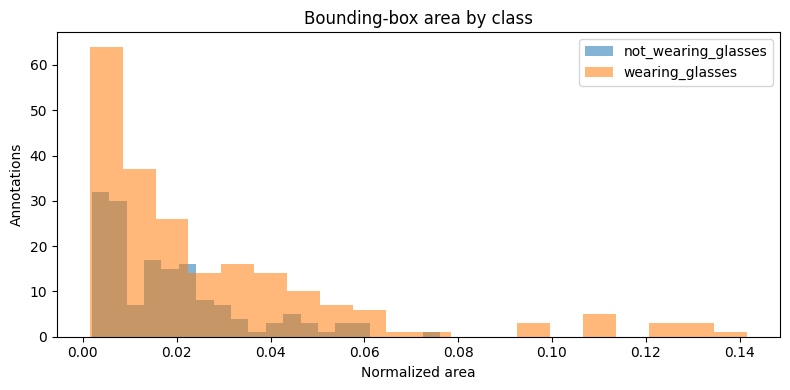

In [14]:
fig = plt.figure(figsize=(8, 4))
for class_name in CLASS_NAMES.values():
    values = annotations_df.loc[annotations_df["class_name"] == class_name, "bbox_area"]
    plt.hist(values, bins=20, alpha=0.55, label=class_name)
plt.title("Bounding-box area by class")
plt.xlabel("Normalized area")
plt.ylabel("Annotations")
plt.legend()
plt.tight_layout()
plt.show()


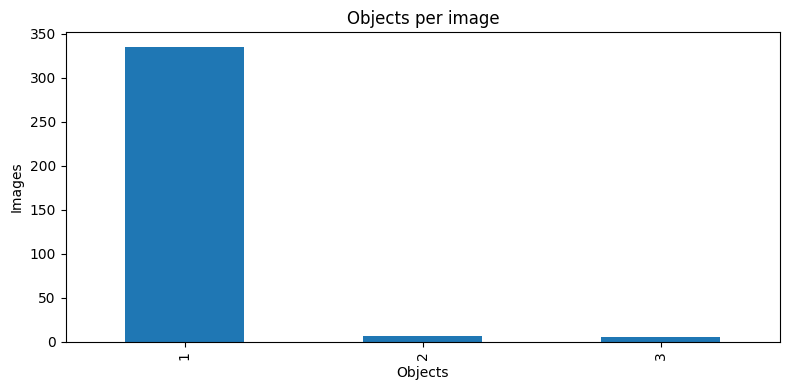

In [15]:
objects_per_image = images_df["objects"].value_counts().sort_index()
ax = objects_per_image.plot(kind="bar", figsize=(8, 4), title="Objects per image")
ax.set_xlabel("Objects")
ax.set_ylabel("Images")
plt.tight_layout()
plt.show()


## 7. Visual annotation inspection

Randomly sample original images from each split and draw their ground-truth boxes. This is an important pre-training sanity check.


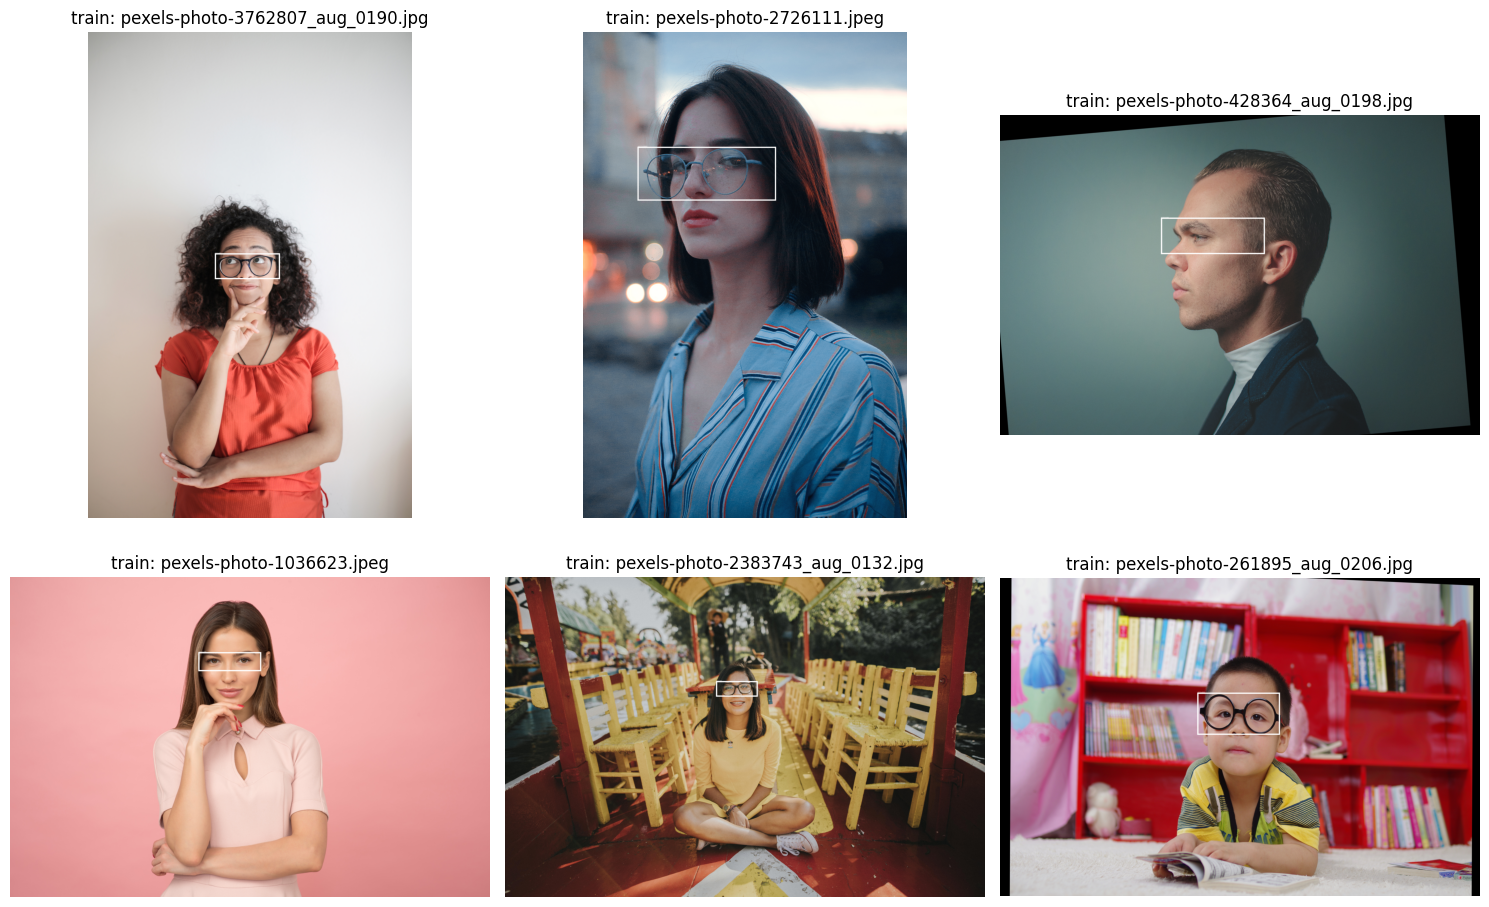

In [16]:
def draw_yolo_boxes(image_path: Path, label_path: Path):
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)
    W, H = image.size
    labels = read_yolo_labels(label_path)
    for cls, xc, yc, w, h in labels:
        x1 = (xc - w / 2) * W
        y1 = (yc - h / 2) * H
        x2 = (xc + w / 2) * W
        y2 = (yc + h / 2) * H
        draw.rectangle((x1, y1, x2, y2), width=max(2, round(min(W, H) / 250)))
        draw.text((x1 + 3, max(0, y1 - 12)), CLASS_NAMES.get(cls, str(cls)))
    return image

def show_ground_truth(split="train", n=6):
    subset = images_df[images_df["split"] == split]
    n = min(n, len(subset))
    sample = subset.sample(n=n, random_state=SEED)
    cols = 3
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, row) in zip(axes, sample.iterrows()):
        im = draw_yolo_boxes(Path(row.image_path), Path(row.label_path))
        ax.imshow(im)
        ax.set_title(f"{split}: {row.image}")
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_ground_truth("train", 6)


## 8. Training configuration

The dataset is small and already contains offline augmented training images, so online augmentation is deliberately conservative. Validation/test are not augmented. Early stopping is enabled.


In [17]:
EPOCHS = 100
IMAGE_SIZE = 640
BATCH_SIZE = 8
PATIENCE = 20
WORKERS = 4
DEVICE = 0 if torch.cuda.is_available() else "cpu"

training_config = {
    "model": MODEL_WEIGHTS, "epochs": EPOCHS, "imgsz": IMAGE_SIZE,
    "batch": BATCH_SIZE, "patience": PATIENCE, "device": DEVICE,
    "workers": WORKERS, "optimizer": "AdamW", "lr0": 0.001,
    "lrf": 0.01, "weight_decay": 0.0005, "seed": SEED,
}
training_config


{'model': 'yolo12m.pt',
 'epochs': 100,
 'imgsz': 640,
 'batch': 8,
 'patience': 20,
 'device': 0,
 'workers': 4,
 'optimizer': 'AdamW',
 'lr0': 0.001,
 'lrf': 0.01,
 'weight_decay': 0.0005,
 'seed': 42}

## 9. Fine-tune pretrained YOLO12m

**Windows note:** notebooks normally avoid the script-level multiprocessing problem you encountered. If your Jupyter environment still raises a worker-spawn error, set `WORKERS = 0` and rerun this cell. This affects data loading throughput, not the model itself.


In [18]:
model = YOLO(MODEL_WEIGHTS)

train_results = model.train(
    data=str(DATASET_YAML),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    patience=PATIENCE,
    device=DEVICE,
    workers=WORKERS,
    pretrained=True,
    freeze=None,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,
    seed=SEED,
    deterministic=True,
    hsv_h=0.01,
    hsv_s=0.3,
    hsv_v=0.2,
    degrees=3.0,
    translate=0.05,
    scale=0.10,
    shear=0.0,
    fliplr=0.5,
    flipud=0.0,
    mosaic=0.0,
    mixup=0.0,
    project=str(PROJECT_DIR),
    name=RUN_NAME,
    save=True,
    save_period=10,
    plots=True,
    verbose=True,
    exist_ok=True,
)


New https://pypi.org/project/ultralytics/8.4.167 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.164  Python-3.10.20 torch-2.14.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4090 Laptop GPU, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data\DST_GlassesDet\yolo.yaml, degrees=3.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.3, hsv_v=0.2, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mo

## 10. Training curves


In [23]:
RUN_DIR = PROJECT_DIR / RUN_NAME
BEST_MODEL = r"runs\detect\runs\yolo12m_glassesdet_notebook\weights\best.pt"
LAST_MODEL = r"runs\detect\runs\yolo12m_glassesdet_notebook\weights\last.pt"
RESULTS_CSV = r"runs\detect\runs\yolo12m_glassesdet_notebook\results.csv"

history = pd.read_csv(RESULTS_CSV)
history.columns = [c.strip() for c in history.columns]
display(history.tail())


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
50,51,452.151,0.66601,0.40938,1.00322,0.90401,0.81250,0.88667,0.43295,1.92977,0.89793,2.07719,0.000505,0.000505,0.000505
51,52,460.860,0.66692,0.40886,0.99123,0.97450,0.86290,0.92056,0.48510,1.80452,0.94850,2.00480,0.000495,0.000495,0.000495
52,53,469.361,0.66333,0.40600,0.99376,0.91023,0.86987,0.89167,0.45524,1.74241,0.92116,1.78881,0.000485,0.000485,0.000485
53,54,477.833,0.67834,0.41908,0.99648,0.97172,0.93750,0.93500,0.44150,1.86349,0.79430,1.99617,0.000475,0.000475,0.000475
54,55,485.932,0.66281,0.41126,0.99673,0.97425,0.93750,0.93500,0.51681,1.78907,0.87873,1.94074,0.000465,0.000465,0.000465


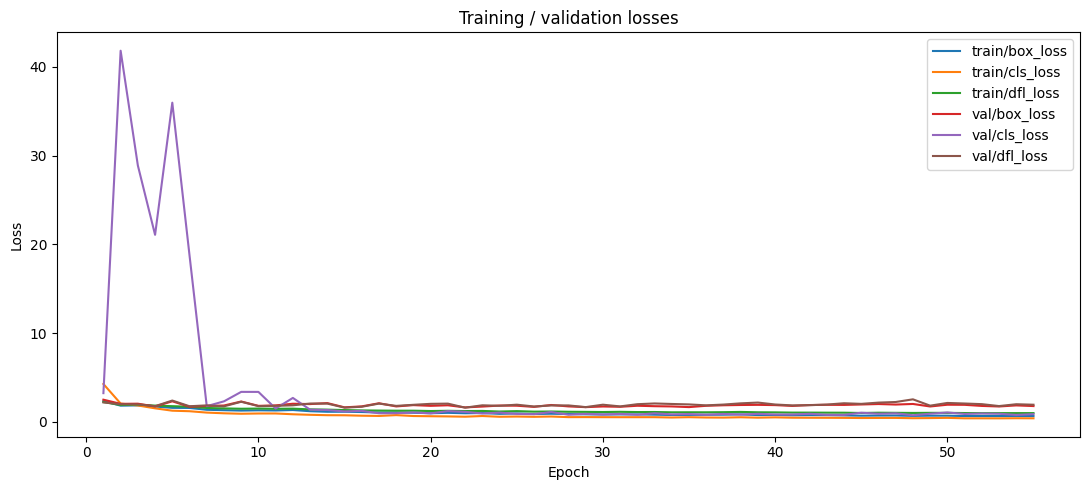

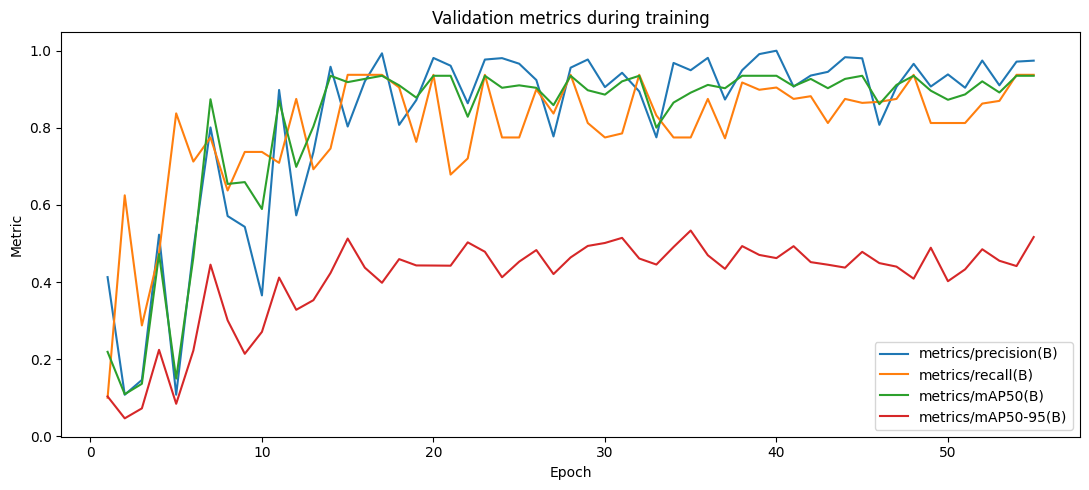

In [24]:
if history is not None:
    metric_cols = [c for c in history.columns if c.startswith("metrics/")]
    loss_cols = [c for c in history.columns if "loss" in c]

    if loss_cols:
        plt.figure(figsize=(11, 5))
        for c in loss_cols:
            plt.plot(history["epoch"], history[c], label=c)
        plt.title("Training / validation losses")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.tight_layout()
        plt.show()

    if metric_cols:
        plt.figure(figsize=(11, 5))
        for c in metric_cols:
            plt.plot(history["epoch"], history[c], label=c)
        plt.title("Validation metrics during training")
        plt.xlabel("Epoch")
        plt.ylabel("Metric")
        plt.legend()
        plt.tight_layout()
        plt.show()


## 11. Evaluate the best checkpoint

First evaluate on validation for model-development diagnostics, then separately on the held-out test split for the final experiment result.


In [25]:
best_model = YOLO(str(BEST_MODEL))

val_metrics = best_model.val(
    data=str(DATASET_YAML), split="val", imgsz=IMAGE_SIZE, batch=BATCH_SIZE,
    device=DEVICE, plots=True, project=str(PROJECT_DIR),
    name=f"{RUN_NAME}_val_eval", exist_ok=True, verbose=True,
)


Ultralytics 8.4.164  Python-3.10.20 torch-2.14.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4090 Laptop GPU, 16376MiB)
YOLOv12m summary (fused): 169 layers, 20,106,454 parameters, 0 gradients, 70.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2355.9181.2 MB/s, size: 7072.6 KB)
val: Scanning C:\Users\oalyami\CAV-DDE\Repos\External\GlassesDet\data\DST_GlassesDet\val\labels.cache... 12 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12/12  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.6s/it 3.1s<10.2s
                   all         12         13      0.908      0.775       0.87      0.529
   not_wearing_glasses          5          5      0.962        0.8      0.962      0.625
       wearing_glasses          7          8      0.855       0.75      0.777      0.433
Speed: 1.8ms preprocess, 39.6ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to C:\Users\oalyami\CAV-DDE\Repos\External\GlassesDet\r

In [26]:
test_metrics = best_model.val(
    data=str(DATASET_YAML), split="test", imgsz=IMAGE_SIZE, batch=BATCH_SIZE,
    device=DEVICE, plots=True, project=str(PROJECT_DIR),
    name=f"{RUN_NAME}_test_eval", exist_ok=True, verbose=True,
)


Ultralytics 8.4.164  Python-3.10.20 torch-2.14.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4090 Laptop GPU, 16376MiB)
YOLOv12m summary (fused): 169 layers, 20,106,454 parameters, 0 gradients, 70.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1176.0226.1 MB/s, size: 9183.9 KB)
val: Scanning C:\Users\oalyami\CAV-DDE\Repos\External\GlassesDet\data\DST_GlassesDet\test\labels... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 1.2Kit/s 0.0s
val: New cache created: C:\Users\oalyami\CAV-DDE\Repos\External\GlassesDet\data\DST_GlassesDet\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.3s/it 2.5s8.2s
                   all         15         15      0.803       0.79      0.823      0.423
   not_wearing_glasses          7          7      0.732      0.714       0.82       0.41
       wearing_glasses          8          8      0.874      0.865      0.827      0.436
Speed: 1.4ms preprocess, 20.1ms infere

## 12. Overall and per-class test metrics


In [27]:
def summarize_detection_metrics(metrics, class_names):
    box = metrics.box
    p, r = float(box.mp), float(box.mr)
    overall_f1 = 2 * p * r / (p + r) if (p + r) else 0.0
    overall = pd.DataFrame([{
        "precision": p, "recall": r, "f1": overall_f1,
        "mAP50": float(box.map50), "mAP50-95": float(box.map),
    }])

    rows = []
    for class_id, class_name in class_names.items():
        result = box.class_result(class_id)
        cp, cr, cap50, cap = map(float, result[:4])
        cf1 = 2 * cp * cr / (cp + cr) if (cp + cr) else 0.0
        rows.append({
            "class_id": class_id, "class": class_name, "precision": cp,
            "recall": cr, "f1": cf1, "mAP50": cap50, "mAP50-95": cap,
        })
    return overall, pd.DataFrame(rows)

overall_test, per_class_test = summarize_detection_metrics(test_metrics, CLASS_NAMES)
print("Held-out TEST metrics")
display(overall_test.round(4))
display(per_class_test.round(4))


Held-out TEST metrics


,precision,recall,f1,mAP50,mAP50-95
0,0.8026,0.7895,0.796,0.8233,0.4231


,class_id,class,precision,recall,f1,mAP50,mAP50-95
0,0,not_wearing_glasses,0.7316,0.7143,0.7228,0.8200,0.4105
1,1,wearing_glasses,0.8735,0.8647,0.8691,0.8266,0.4356


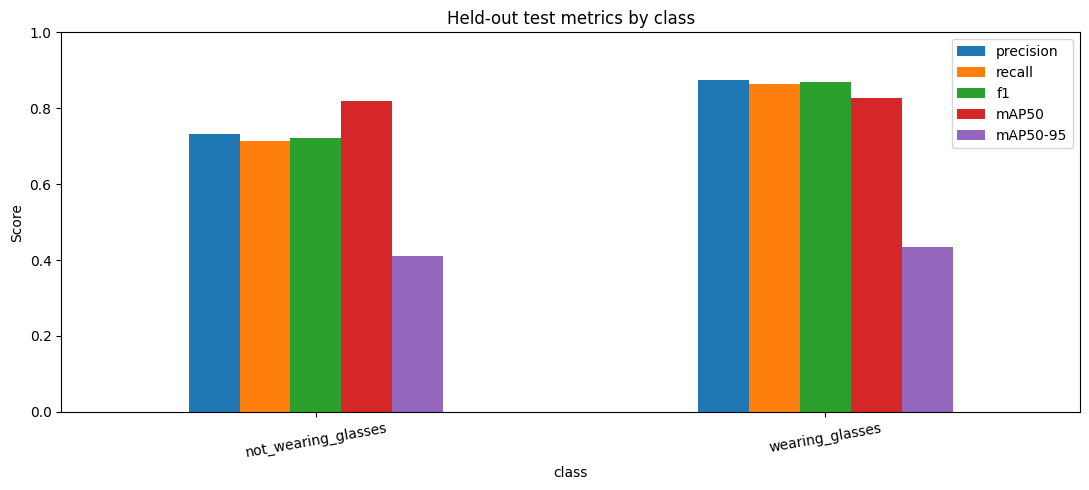

In [28]:
ax = per_class_test.set_index("class")[["precision", "recall", "f1", "mAP50", "mAP50-95"]].plot(
    kind="bar", figsize=(11, 5), ylim=(0, 1), title="Held-out test metrics by class"
)
ax.set_ylabel("Score")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


## 13. Ultralytics evaluation artifacts


Test evaluation artifacts: C:\Users\oalyami\CAV-DDE\Repos\External\GlassesDet\runs\detect\runs\yolo12m_glassesdet_notebook_test_eval


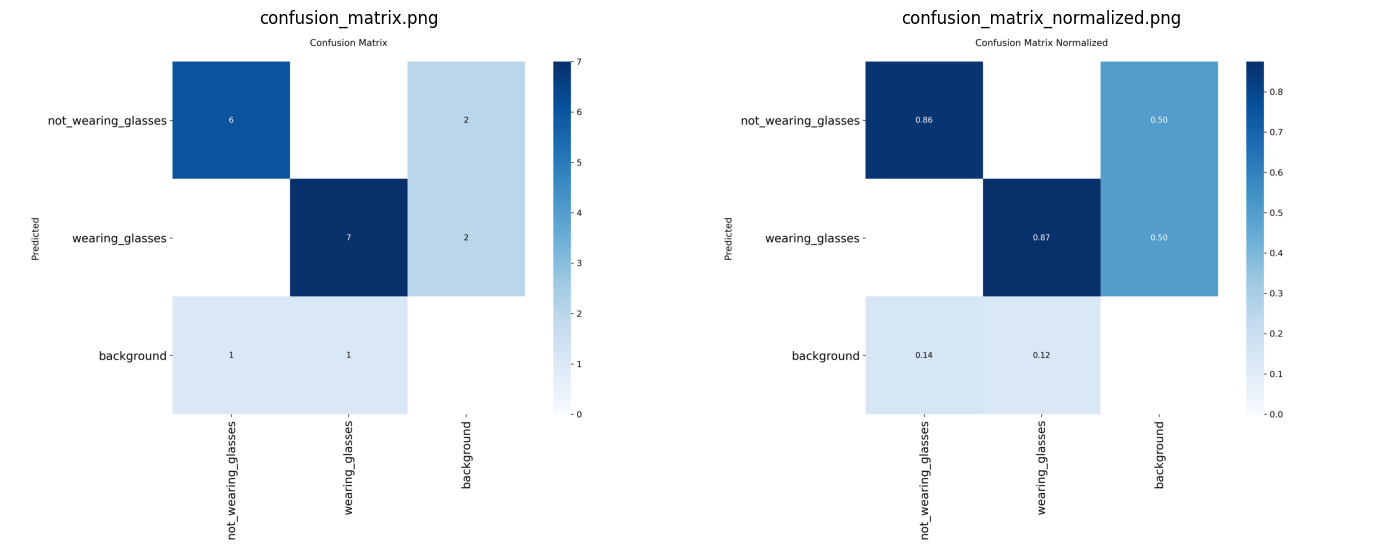

In [29]:
test_eval_dir = Path(test_metrics.save_dir)
print(f"Test evaluation artifacts: {test_eval_dir}")

artifact_names = [
    "confusion_matrix.png", "confusion_matrix_normalized.png",
    "PR_curve.png", "F1_curve.png", "P_curve.png", "R_curve.png",
]

figures = [test_eval_dir / name for name in artifact_names if (test_eval_dir / name).exists()]
if figures:
    cols = 2
    rows = math.ceil(len(figures) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 6 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, path in zip(axes, figures):
        ax.imshow(Image.open(path))
        ax.set_title(path.name)
        ax.axis("off")
    for ax in axes[len(figures):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No plot artifacts found. Ensure plots=True during evaluation.")


## 14. Qualitative predictions on held-out test images


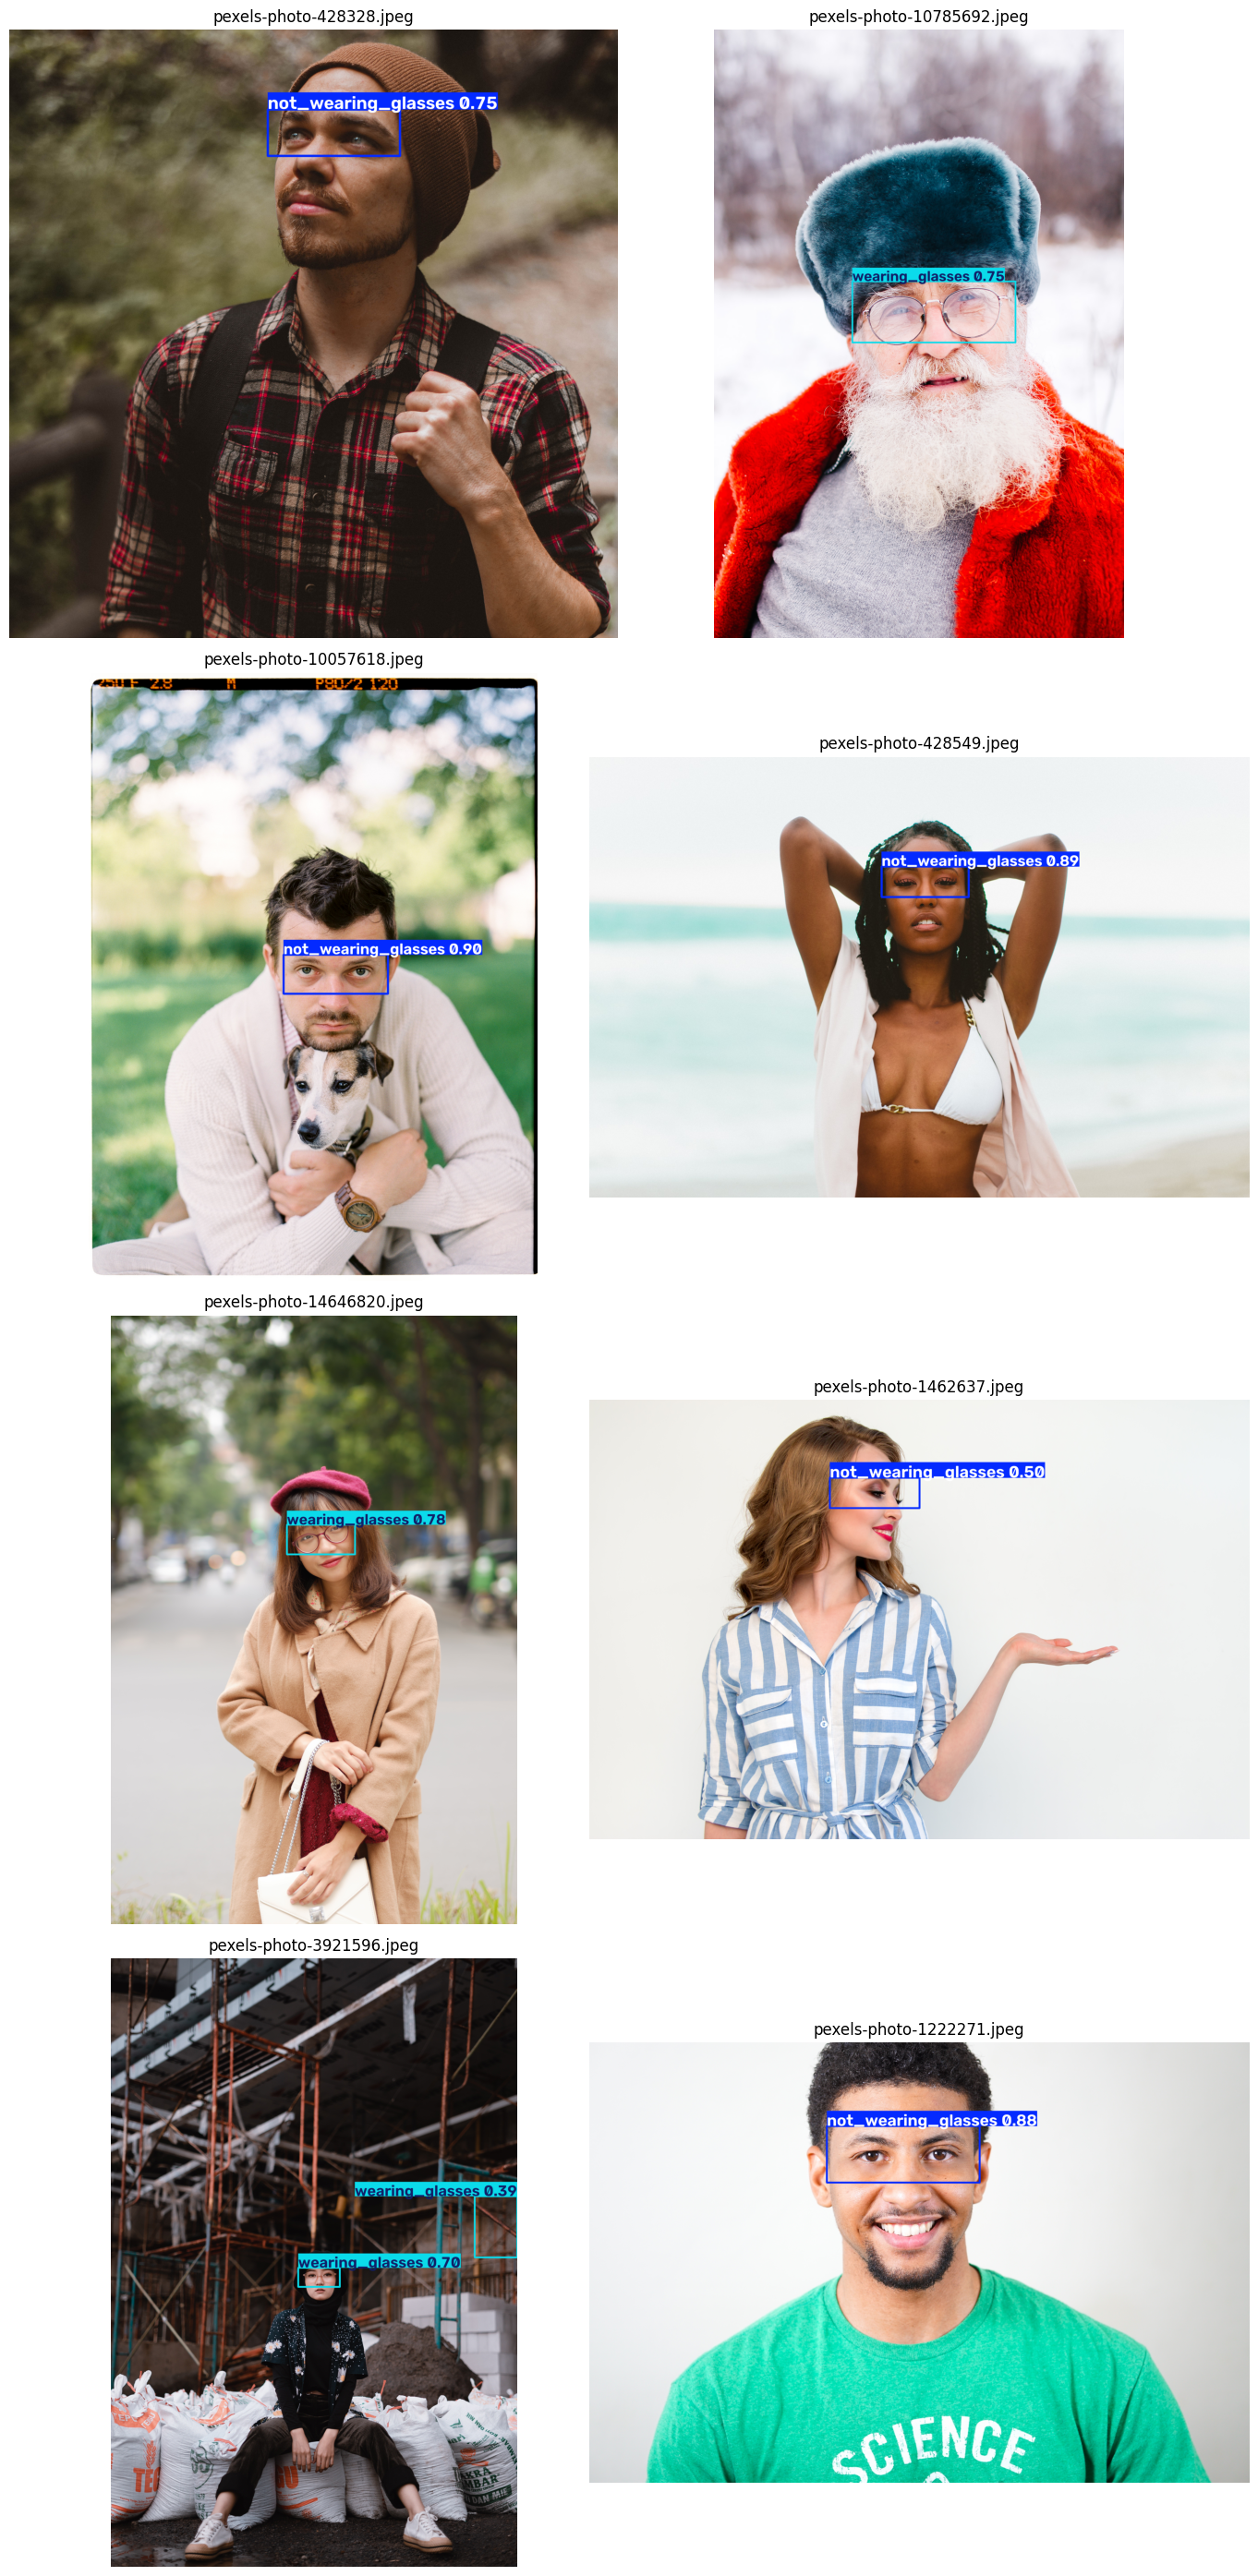

In [30]:
test_images = image_files(DATASET_DIR / "test" / "images")
qualitative_sample = random.Random(SEED).sample(test_images, min(8, len(test_images)))

predictions = best_model.predict(
    source=[str(p) for p in qualitative_sample], imgsz=IMAGE_SIZE, conf=0.25,
    device=DEVICE, verbose=False,
)

cols = 2
rows = math.ceil(len(predictions) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(14, 7 * rows))
axes = np.atleast_1d(axes).ravel()
for ax, result in zip(axes, predictions):
    plotted = result.plot()[:, :, ::-1]  # BGR -> RGB
    ax.imshow(plotted)
    ax.set_title(Path(result.path).name)
    ax.axis("off")
for ax in axes[len(predictions):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


## 15. Experiment summary

Use this section as the compact record of the run. With only a small number of original validation/test images, interpret metric changes carefully: individual errors can materially move precision, recall, and AP.


In [31]:
summary = {
    "model": MODEL_WEIGHTS,
    "best_checkpoint": str(BEST_MODEL),
    "dataset_images": int(len(images_df)),
    "dataset_annotations": int(len(annotations_df)),
    "split_images": split_summary["images"].to_dict(),
    "class_annotations": class_totals.to_dict(),
    "test_precision": float(overall_test.iloc[0]["precision"]),
    "test_recall": float(overall_test.iloc[0]["recall"]),
    "test_f1": float(overall_test.iloc[0]["f1"]),
    "test_mAP50": float(overall_test.iloc[0]["mAP50"]),
    "test_mAP50_95": float(overall_test.iloc[0]["mAP50-95"]),
}
summary


{'model': 'yolo12m.pt',
 'best_checkpoint': 'runs\\detect\\runs\\yolo12m_glassesdet_notebook\\weights\\best.pt',
 'dataset_images': 348,
 'dataset_annotations': 367,
 'split_images': {'train': 321, 'val': 12, 'test': 15},
 'class_annotations': {'not_wearing_glasses': 156, 'wearing_glasses': 211},
 'test_precision': 0.8025570113415526,
 'test_recall': 0.7895103412438906,
 'test_f1': 0.795980218880772,
 'test_mAP50': 0.8233088235294118,
 'test_mAP50_95': 0.42305231092436985}

## 16. Real-Time Webcam Detection

Run the stand-alone python script: `live_inference.py`

# 11. Conclusion and Results Summary

This project developed an end-to-end computer vision pipeline for detecting whether a person is **wearing glasses** or **not wearing glasses** using a fine-tuned **YOLO12m** object detection model.

The complete workflow covered dataset preparation, exploratory data analysis, annotation inspection, data augmentation, transfer learning, quantitative evaluation, qualitative prediction analysis, and real-time webcam inference.

## Final Evaluation Results

After training, the best-performing checkpoint (`best.pt`) was evaluated on both the validation set and the held-out test set.

### Overall Performance

| Dataset | Precision | Recall | F1 Score | mAP@0.50 | mAP@0.50:0.95 |
|---|---:|---:|---:|---:|---:|
| Validation | 0.908 | 0.775 | 0.837 | 0.870 | 0.529 |
| **Test** | **0.803** | **0.790** | **0.796** | **0.823** | **0.423** |

The final held-out test evaluation achieved approximately **80.3% precision**, **79.0% recall**, and an **F1 score of 79.6%**.

The model also achieved an **mAP@0.50 of 82.3%**, indicating strong detection performance when an IoU threshold of 0.50 is used. The stricter **mAP@0.50:0.95 was 42.3%**, showing that performance decreases as increasingly precise bounding-box localization is required.

The difference between mAP@0.50 and mAP@0.50:0.95 suggests that the model is generally successful at identifying and locating the target objects, while precise bounding-box localization remains an area where further improvement is possible.

## Per-Class Test Performance

The held-out test results show a noticeable difference between the two classes:

| Class | Precision | Recall | F1 Score | mAP@0.50 | mAP@0.50:0.95 |
|---|---:|---:|---:|---:|---:|
| `not_wearing_glasses` | 0.732 | 0.714 | 0.723 | 0.820 | 0.410 |
| `wearing_glasses` | **0.874** | **0.865** | **0.869** | **0.827** | **0.436** |

The model performed more consistently on the **`wearing_glasses`** class, achieving **87.4% precision**, **86.5% recall**, and an **86.9% F1 score**.

The **`not_wearing_glasses`** class was more challenging, with **73.2% precision**, **71.4% recall**, and a **72.3% F1 score**.

Interestingly, the mAP@0.50 values for the two classes were very similar — **82.0%** for `not_wearing_glasses` and **82.7%** for `wearing_glasses`. This suggests that both classes can be detected reasonably well overall, although the final confidence-based precision and recall behavior favors the `wearing_glasses` class.

## Confusion Matrix Analysis

The confusion matrix provides additional insight into the model's behavior on the held-out test set.

For the ground-truth objects, the model correctly detected:

- **6 of 7** `not_wearing_glasses` instances.
- **7 of 8** `wearing_glasses` instances.

This corresponds closely to the class recall values of **71.4%** and **86.5%**, respectively, once the complete confidence-ranked detection evaluation is considered.

The confusion matrix also shows background-related errors, meaning that some predictions were produced where no corresponding ground-truth object existed and some ground-truth objects were not matched by a prediction.

Importantly, the matrix does not show substantial direct confusion between `wearing_glasses` and `not_wearing_glasses`. The more significant errors are therefore associated with **detecting or missing the object itself**, rather than simply swapping one glasses class for the other.

## Validation vs. Test Performance

The model achieved higher validation performance than test performance:

- Validation mAP@0.50: **87.0%**
- Test mAP@0.50: **82.3%**
- Validation mAP@0.50:0.95: **52.9%**
- Test mAP@0.50:0.95: **42.3%**

A reduction on the completely held-out test set is expected because the model and training process were indirectly optimized using validation performance.

The difference also reinforces the importance of maintaining an independent test set rather than reporting validation metrics alone.

## Project Limitations

The primary limitation of this experiment is the relatively small dataset.

The original dataset contains only **134 independent images**, divided into **107 training**, **12 validation**, and **15 test images**. Data augmentation increased the training set to **321 images**, but these additional samples are transformations of the original training images rather than independently collected observations.

The small test set is especially important when interpreting the final results. With only **15 test images and 15 annotated instances**, a small number of detection errors can noticeably affect precision, recall, and mAP.

The reported metrics should therefore be interpreted as the results of this specific experiment rather than as evidence of production-level performance across a large population of unseen images.

## Future Improvements

The most important improvement would be to collect a significantly larger and more diverse dataset containing:

- More people and facial appearances.
- Different types and styles of glasses.
- Different lighting conditions.
- Different camera angles and distances.
- Different head orientations.
- Partial facial occlusion.
- More complex backgrounds.
- Different image and camera qualities.

A larger independent test set would also provide a more statistically reliable estimate of model generalization.

Further experiments could compare different YOLO model sizes, tune confidence and IoU thresholds, investigate additional augmentation strategies, perform more detailed error analysis, and compare YOLO12m against alternative object detection architectures.

## Final Conclusion

Overall, the fine-tuned YOLO12m detector achieved a **test mAP@0.50 of 82.3%**, with approximately **80.3% precision**, **79.0% recall**, and a **79.6% F1 score** on previously unseen test data.

The model performed particularly well when detecting people **wearing glasses**, while detection of the `not_wearing_glasses` class showed greater room for improvement. The difference between **82.3% mAP@0.50** and **42.3% mAP@0.50:0.95** also indicates that improving bounding-box localization accuracy would be an important target for future work.

Finally, the trained model was successfully integrated into a **real-time webcam inference pipeline**, demonstrating how the final checkpoint can be applied beyond the static dataset to live visual input.

The project therefore demonstrates the complete development cycle of a modern object detection system:

**Dataset Preparation → EDA → Data Augmentation → Transfer Learning → Model Evaluation → Error Analysis → Real-Time Inference**

The experiment shows how transfer learning can be used to adapt a pretrained object detector to a specialized computer vision task while maintaining a structured, reproducible, and quantitatively evaluated workflow.